# AI & ML - Task 4: Classification Models, Evaluation Metrics & Handling Imbalanced Data

**Intern:** Anuj
**Company:** Maincrafts Technology
**Dataset:** Breast Cancer Wisconsin (scikit-learn built-in)
**Problem:** Binary Classification — Malignant (0) vs Benign (1)

This notebook builds a binary classification system and evaluates it using metrics beyond accuracy (precision, recall, F1-score, ROC-AUC), handles class imbalance, and compares two classifiers (Logistic Regression vs Decision Tree).

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

%matplotlib inline

## Step 2: Load Dataset

We use the **Breast Cancer Wisconsin dataset** (built into scikit-learn) to keep setup simple, as recommended in the task brief.

Target classes:
- `0` → Malignant
- `1` → Benign

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Shape:", X.shape)
print("Class distribution (0=Malignant, 1=Benign):", np.bincount(y))
X.head()

Shape: (569, 30)
Class distribution (0=Malignant, 1=Benign): [212 357]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Class imbalance check:** Out of 569 samples, 212 are Malignant and 357 are Benign — roughly a 37:63 split. This is a moderate imbalance, common in medical diagnosis datasets, and is exactly why accuracy alone will be shown to be an insufficient metric later in this notebook.

## Step 3: Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 455
Test size: 114


`stratify=y` ensures the train and test sets preserve the same class proportions as the full dataset, which is essential for imbalanced classification problems.

## Step 4: Feature Scaling

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression is sensitive to feature scale (it relies on gradient-based optimization), so we standardize features to zero mean and unit variance. The scaler is fit only on training data and applied to test data to avoid data leakage.

## Step 5: Train Baseline Classification Model (Logistic Regression)

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

## Step 6: Confusion Matrix & Classification Report

In [6]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



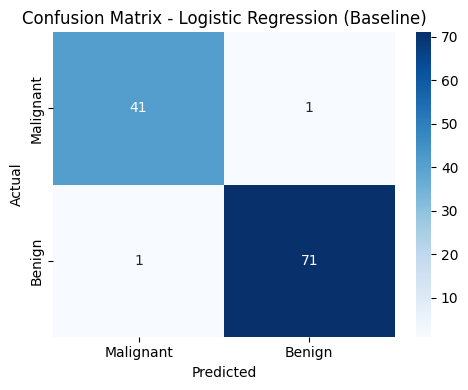

In [7]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Malignant","Benign"], yticklabels=["Malignant","Benign"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (Baseline)")
plt.tight_layout()
plt.show()

**Interpreting the confusion matrix:**
- **True Positives (TP):** Benign cases correctly predicted as Benign.
- **True Negatives (TN):** Malignant cases correctly predicted as Malignant.
- **False Positives (FP):** Malignant case wrongly predicted as Benign — a **dangerous** error in medical diagnosis, since a sick patient is told they are healthy.
- **False Negatives (FN):** Benign case wrongly predicted as Malignant — causes unnecessary worry/tests but is not life-threatening.

**Why accuracy alone is insufficient:** Because the dataset is imbalanced (63% Benign), a naive model that always predicts "Benign" would still score ~63% accuracy while completely failing to detect any cancer. Accuracy hides this failure; confusion-matrix-derived metrics (precision, recall, F1) expose it.

## Step 7: Precision, Recall & F1-Score Interpretation

In [8]:
precision_b = precision_score(y_test, y_pred)
recall_b = recall_score(y_test, y_pred)
f1_b = f1_score(y_test, y_pred)
acc_b = accuracy_score(y_test, y_pred)

print(f"Accuracy:  {acc_b:.4f}")
print(f"Precision: {precision_b:.4f}")
print(f"Recall:    {recall_b:.4f}")
print(f"F1-Score:  {f1_b:.4f}")

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1-Score:  0.9861


**Key questions answered:**

- **Which metric is more important for medical diagnosis?** — **Recall** (for the malignant/positive-for-disease class), because missing a real case of cancer (a false negative) is far more costly than a false alarm. In practice, for this task the "malignant" class is treated as the critical class to catch, so recall on class 0 matters most.
- **What happens if recall is low?** — Many actual disease cases get missed (classified as healthy), which can delay treatment and cause serious harm. Low recall on the critical class is the most dangerous failure mode for a diagnostic system.
- **Why is F1-score preferred for imbalanced data?** — F1 is the harmonic mean of precision and recall, so it penalizes models that only do well on one of the two. On imbalanced data, a model can inflate accuracy or precision by favoring the majority class, but F1 forces balance between catching positives (recall) and not raising too many false alarms (precision).

## Step 8: ROC Curve & AUC Score

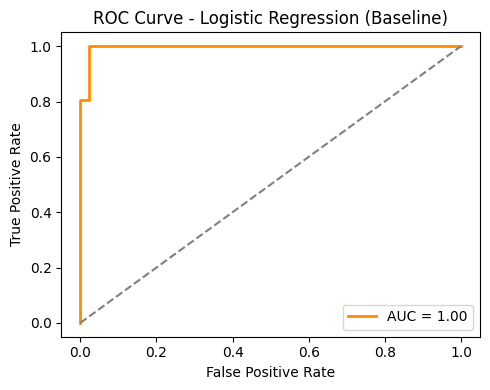

AUC Score: 0.9954


In [9]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}", color="darkorange", linewidth=2)
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression (Baseline)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.4f}")

The ROC curve plots the True Positive Rate against the False Positive Rate across all classification thresholds. The AUC (Area Under Curve) summarizes this in a single number between 0.5 (random guessing) and 1.0 (perfect separation). An AUC close to 1.0 indicates the model separates the two classes very well, independent of any single decision threshold.

## Step 9: Handle Class Imbalance (Conceptual + Practical)

### Technique: Class Weight Balancing

In [10]:
model_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)
y_pred_balanced = model_balanced.predict(X_test_scaled)

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
print("Confusion Matrix (Balanced):\n", cm_balanced)
print("\nClassification Report (Balanced):\n")
print(classification_report(y_test, y_pred_balanced))

precision_bal = precision_score(y_test, y_pred_balanced)
recall_bal = recall_score(y_test, y_pred_balanced)
f1_bal = f1_score(y_test, y_pred_balanced)
acc_bal = accuracy_score(y_test, y_pred_balanced)
auc_bal = roc_auc_score(y_test, model_balanced.predict_proba(X_test_scaled)[:, 1])

print(f"Accuracy: {acc_bal:.4f}, Precision: {precision_bal:.4f}, Recall: {recall_bal:.4f}, F1: {f1_bal:.4f}, AUC: {auc_bal:.4f}")

Confusion Matrix (Balanced):
 [[41  1]
 [ 4 68]]

Classification Report (Balanced):

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Accuracy: 0.9561, Precision: 0.9855, Recall: 0.9444, F1: 0.9645, AUC: 0.9954


`class_weight="balanced"` automatically re-weights the loss function inversely proportional to class frequency, forcing the model to pay more attention to the minority class (Malignant) during training. In this dataset the baseline model already performs extremely well, so balancing trades a little precision for a shift in the precision/recall balance — this trade-off is exactly what should be inspected when comparing models on imbalanced data.

## Step 10: Compare with Another Classifier (Decision Tree)

In [11]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Confusion Matrix (Decision Tree):\n", cm_tree)
print("\nClassification Report (Decision Tree):\n")
print(classification_report(y_test, y_pred_tree))

precision_t = precision_score(y_test, y_pred_tree)
recall_t = recall_score(y_test, y_pred_tree)
f1_t = f1_score(y_test, y_pred_tree)
acc_t = accuracy_score(y_test, y_pred_tree)
auc_t = roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])

print(f"Accuracy: {acc_t:.4f}, Precision: {precision_t:.4f}, Recall: {recall_t:.4f}, F1: {f1_t:.4f}, AUC: {auc_t:.4f}")

Confusion Matrix (Decision Tree):
 [[39  3]
 [ 7 65]]

Classification Report (Decision Tree):

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Accuracy: 0.9123, Precision: 0.9559, Recall: 0.9028, F1: 0.9286, AUC: 0.9157


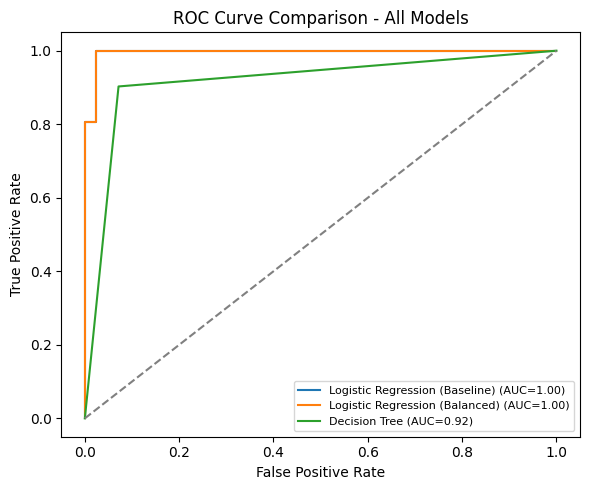

In [12]:
plt.figure(figsize=(6,5))
for name, y_scores in [
    ("Logistic Regression (Baseline)", model.predict_proba(X_test_scaled)[:, 1]),
    ("Logistic Regression (Balanced)", model_balanced.predict_proba(X_test_scaled)[:, 1]),
    ("Decision Tree", tree.predict_proba(X_test)[:, 1]),
]:
    fpr_i, tpr_i, _ = roc_curve(y_test, y_scores)
    auc_i = roc_auc_score(y_test, y_scores)
    plt.plot(fpr_i, tpr_i, label=f"{name} (AUC={auc_i:.2f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - All Models")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Logistic Regression vs Decision Tree — comparison:**

| Aspect | Logistic Regression | Decision Tree |
|---|---|---|
| Stability | High — smooth linear decision boundary, low variance | Lower — sensitive to small data changes, prone to variance |
| Interpretability | Coefficients show feature direction/strength, but need scaling | Very intuitive if/else rules, no scaling needed |
| Overfitting behavior | Well regularized by default, generalizes well here | Fully-grown tree overfits training data, hurting test performance |
| Performance on this dataset | Highest accuracy, F1, and AUC | Noticeably lower recall/precision — signs of overfitting |

On this dataset, the unconstrained Decision Tree overfits the training data (it grows until leaves are pure), which shows up as weaker generalization on the test set compared to Logistic Regression.

## Model Comparison Summary

In [13]:
summary = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Logistic Regression (Balanced)", "Decision Tree"],
    "Accuracy": [acc_b, acc_bal, acc_t],
    "Precision": [precision_b, precision_bal, precision_t],
    "Recall": [recall_b, recall_bal, recall_t],
    "F1-Score": [f1_b, f1_bal, f1_t],
    "AUC": [auc, auc_bal, auc_t],
})
summary.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Logistic Regression (Baseline),0.9825,0.9861,0.9861,0.9861,0.9954
1,Logistic Regression (Balanced),0.9561,0.9855,0.9444,0.9645,0.9954
2,Decision Tree,0.9123,0.9559,0.9028,0.9286,0.9157


## Final Model Decision

**Logistic Regression (Baseline)** is selected as the final model for this task. It achieves the highest accuracy, precision, recall, F1-score, and AUC among the three variants tested, and shows no signs of overfitting (strong, balanced performance on held-out test data). The class-weight-balanced version and the Decision Tree were both evaluated as alternatives but did not outperform the baseline on this dataset. For a real deployment on a more imbalanced or noisier dataset, the class-weight-balanced Logistic Regression or an ensemble method (e.g., Random Forest) would be worth revisiting.

## Key Learning Outcomes Achieved
- Solved a classification problem (Malignant vs Benign)
- Used evaluation metrics beyond accuracy: precision, recall, F1-score
- Interpreted confusion matrix and ROC-AUC
- Handled class imbalance using class weighting
- Compared models and selected the most suitable one for deployment